# FORECASTING EXCHANGERATES USING TIME SERIESANALYSIS

### Part 1: Data Preparation and Exploration

In [1]:
## Data Loading:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller,acf,pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.dates as mdates
import statsmodels.tsa.api as smt

In [3]:
df = pd.read_csv('exchange_rate.csv', parse_dates=['date'], index_col='date',dayfirst=True)
exchange= df.iloc[:, 0]
exchange.head()

date
1990-01-01    0.7855
1990-01-02    0.7818
1990-01-03    0.7867
1990-01-04    0.7860
1990-01-05    0.7849
Name: Ex_rate, dtype: float64

In [4]:
exchange.shape

(7588,)

In [5]:
exchange.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Series name: Ex_rate
Non-Null Count  Dtype  
--------------  -----  
7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


In [6]:
##range of the data
print("Date Range:", exchange.index.min(), "to", exchange.index.max())

Date Range: 1990-01-01 00:00:00 to 2010-10-10 00:00:00


In [7]:
exchange = exchange.sort_index()

In [8]:
## Initial Exploration:

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(exchange, color='blue')
plt.title("Time Series Plot")
plt.xlabel("Date")
plt.ylabel("Value")
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().grid(True)
plt.show()

In [10]:
## Data Preprocessing:

In [11]:
## missing value
exchange.isna().sum()

np.int64(0)

In [12]:
## anomalies
z = (exchange - exchange.mean()) / exchange.std()
anomalies = exchange[np.abs(z) > 3]
print("Number of anomalies:", len(anomalies))
print(anomalies.head())

Number of anomalies: 0
Series([], Name: Ex_rate, dtype: float64)


### Part 2: Model Building 

#### ARIMA

In [13]:
## Parameter Selection for ARIMA:

In [14]:
def test_stationarity(timeseries):

    #Calculate rolling mean and rolling standard deviation
    rolmean = timeseries.rolling(window = 30).mean()
    rolstd = timeseries.rolling(window = 30).std()

    original = plt.plot(timeseries, color = 'blue', label = 'Original')
    mean = plt.plot(rolmean, color = 'red', label = 'Rolling Mean')
    std = plt.plot(rolstd, color = 'green', label = 'Rolling Std')
    plt.legend(loc='best')


    print('Results of Dickey-Fuller Test :\n')
    df_test = adfuller(timeseries)
    my_output = pd.Series(df_test[0:4], index =['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for i,j in df_test[4].items():
        my_output['Critical Value (%s)'%i] =j
    print(my_output)

Results of Dickey-Fuller Test :

Test Statistic                   -1.664994
p-value                           0.449233
#Lags Used                        1.000000
Number of Observations Used    7586.000000
Critical Value (1%)              -3.431212
Critical Value (5%)              -2.861921
Critical Value (10%)             -2.566973
dtype: float64


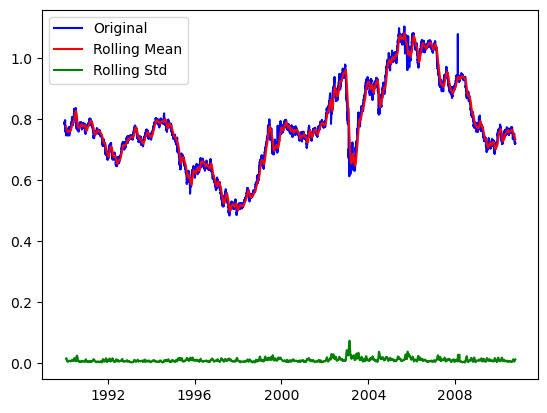

In [15]:
test_stationarity(exchange)

In [16]:
## differencing
exchange_diff = exchange.diff().dropna()

Results of Dickey-Fuller Test :

Test Statistic                  -99.393431
p-value                           0.000000
#Lags Used                        0.000000
Number of Observations Used    7586.000000
Critical Value (1%)              -3.431212
Critical Value (5%)              -2.861921
Critical Value (10%)             -2.566973
dtype: float64


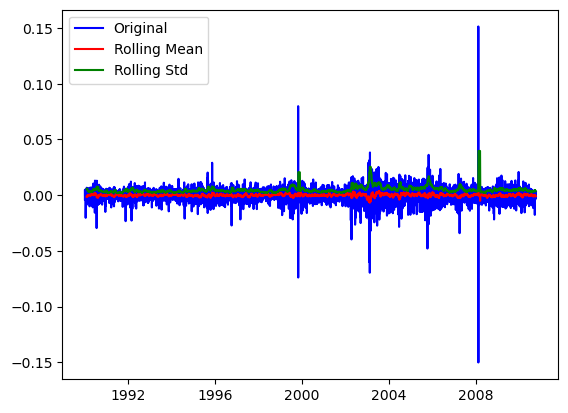

In [17]:
test_stationarity(exchange_diff)

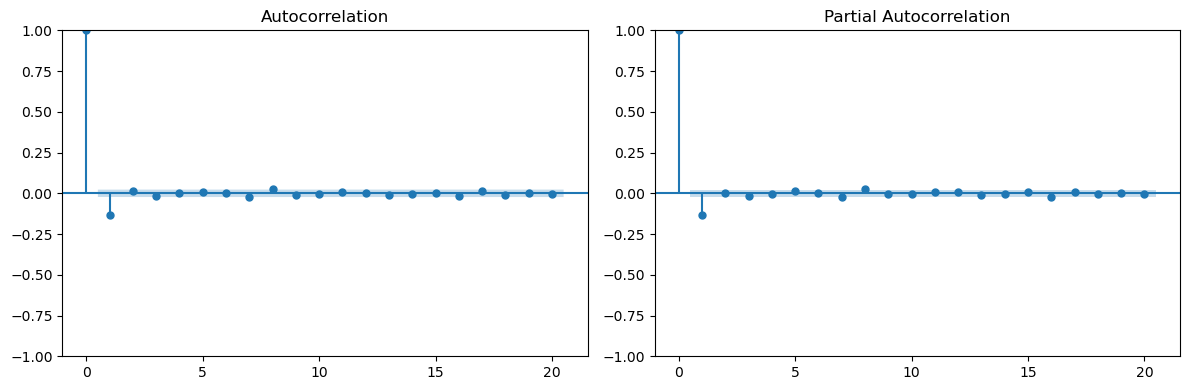

In [18]:
## acf and pcf
fig, axes = plt.subplots(1, 2)
fig.set_figwidth(12)
fig.set_figheight(4)
smt.graphics.plot_acf(exchange_diff, lags=20, ax=axes[0])
smt.graphics.plot_pacf(exchange_diff, lags=20, ax=axes[1])
plt.tight_layout()

In [19]:
## Model Fitting:

In [20]:
import warnings
warnings.filterwarnings('ignore')
model = ARIMA(exchange, order=(1,1,1))

In [21]:
result= model.fit()

In [22]:
## Residual Diagnostics:

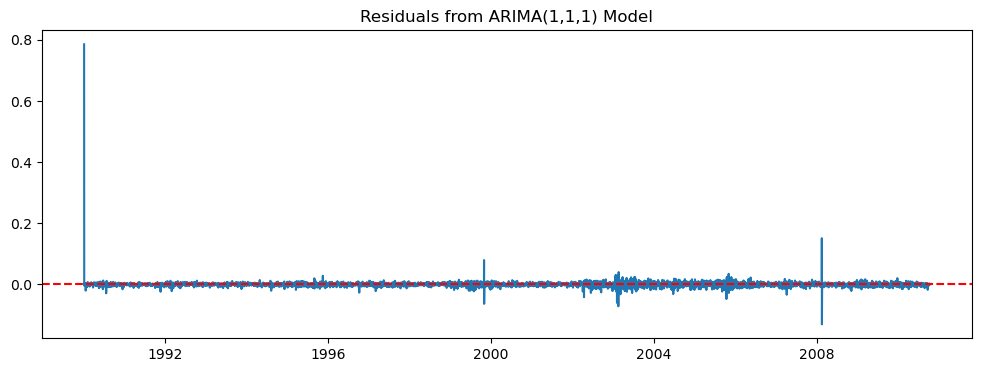

In [23]:
residuals = result.resid
# 1. Residual plot
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Residuals from ARIMA(1,1,1) Model")
plt.axhline(0, color='red', linestyle='--')
plt.show()


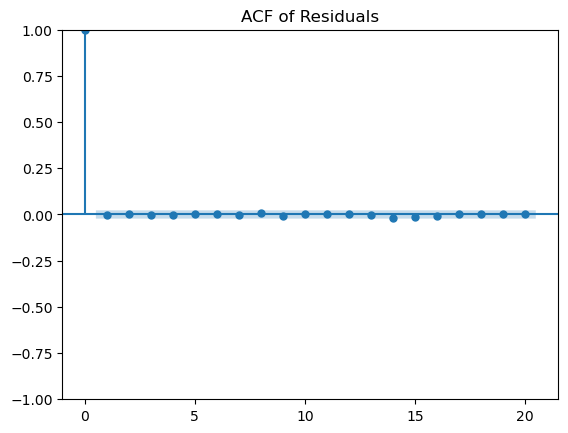

In [24]:
# 2. ACF of residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=20)
plt.title("ACF of Residuals")
plt.show()

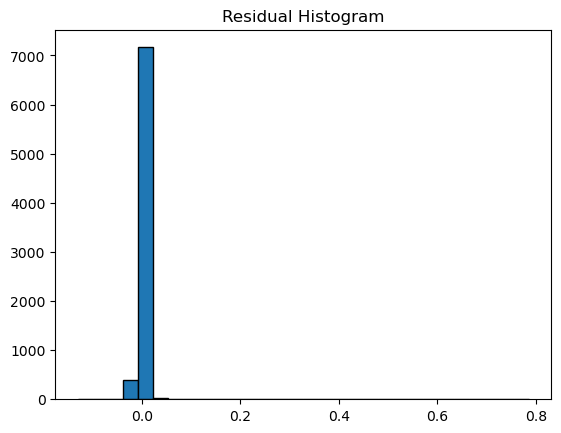

In [25]:
# 3. Histogram
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Residual Histogram")
plt.show()

In [26]:
## Forecasting:

In [27]:
plot_df = pd.DataFrame()
plot_df['actual'] = exchange
plot_df['fitted'] = result.fittedvalues

In [28]:
forecast_obj = result.get_forecast(steps=365)
forecast_values = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int()

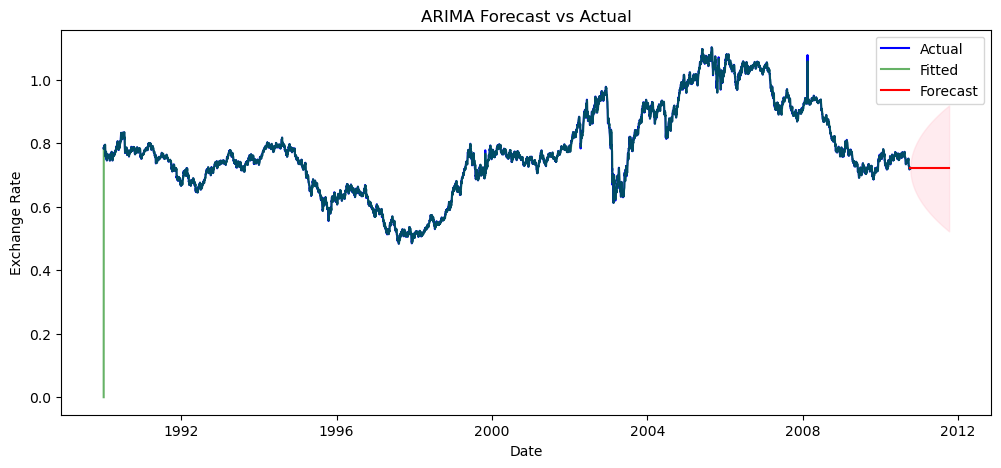

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
# Actual values
plt.plot(plot_df['actual'], label='Actual', color='blue')

# Fitted values (in-sample)
plt.plot(plot_df['fitted'], label='Fitted', color='green',alpha=0.6)

# Forecasted future values
plt.plot(forecast_values, label='Forecast', color='red')

# Confidence interval
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color='pink', alpha=0.3)

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

#### Exponential Smoothing

In [30]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [31]:
# Holt's Linear Trend Exponential Smoothing
hw_model = ExponentialSmoothing(exchange, trend='add', seasonal=None).fit()

In [32]:
## Residual Diagnostics:

In [35]:
hw_fitted = hw_model.fittedvalues
hw_residuals = exchange - hw_fitted

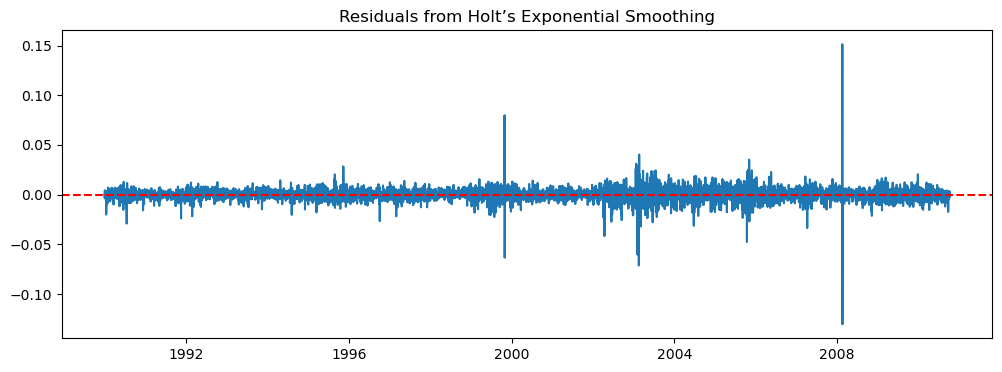

In [36]:
## residual time series
plt.figure(figsize=(12,4))
plt.plot(hw_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals from Holt’s Exponential Smoothing")
plt.show()

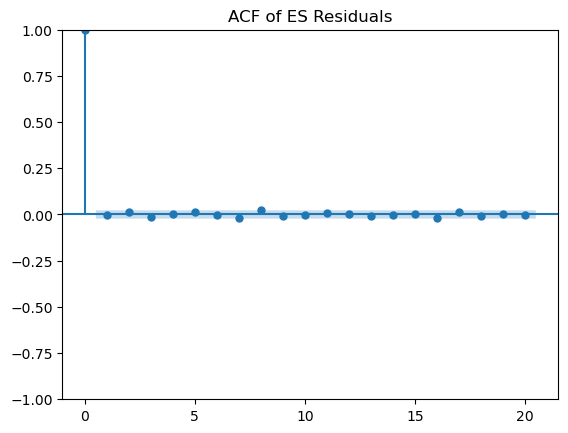

In [37]:
## ACF of residuals
plot_acf(hw_residuals.dropna(), lags=20)
plt.title("ACF of ES Residuals")
plt.show()

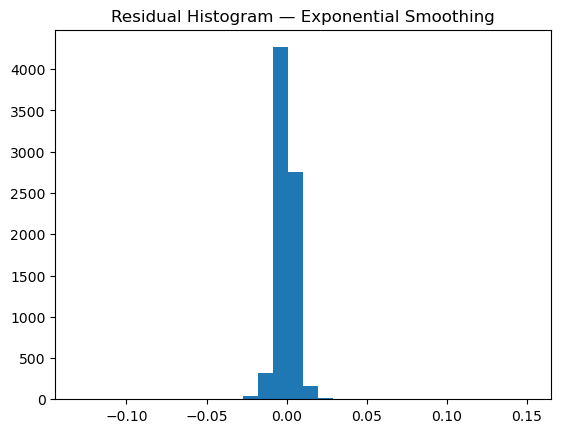

In [38]:
## Residual histogram
plt.hist(hw_residuals, bins=30)
plt.title("Residual Histogram — Exponential Smoothing")
plt.show()

In [39]:
## predicted values
plot_df['hw_fitted'] = hw_fitted

In [40]:
## forecast
hw_forecast = hw_model.forecast(365)

In [ ]:
## visualization
plt.figure(figsize=(12,5))
plt.plot(exchange, label='Actual', color='blue')
plt.plot(hw_fitted, label='ES Fitted', color='orange', alpha=0.7)
plt.plot(hw_forecast, label='ES Forecast', color='red')
plt.title("Exponential Smoothing (Holt's) — Fitted and Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()


The Exponential Smoothing (Holt’s) model provides an excellent fit to the historical exchange rate data, with fitted values almost identical to the actual observations. The future forecast indicates a mild continuation of the recent downward trend, reflecting the model’s emphasis on smoothly extending the existing trend. Overall, Holt’s method performs well for this dataset, which contains clear trend but no seasonality

### Part 3: Evaluation and Comparison:

#### ARIMA

In [ ]:
## Compute Error Metrics: 

In [ ]:
y_true = plot_df['actual']
y_pred = plot_df['fitted']

In [ ]:
# MAE
mae = mean_absolute_error(y_true, y_pred)
mae

In [ ]:
# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
rmse

In [ ]:
# MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
mape

#### Exponential Smoothing

In [ ]:
## mae
hw_mae = mean_absolute_error(exchange, hw_fitted)
hw_mae

In [ ]:
## rmse
hw_rmse = np.sqrt(mean_squared_error(exchange, hw_fitted))
hw_rmse

In [ ]:
## mape
hw_mape = np.mean(np.abs((exchange - hw_fitted) / exchange)) * 100
hw_mape

In [ ]:
## Model Comparison:

In [ ]:
## Conclusion: .